# Fertility-related health and lifestyle indicators

The dataset is from [https://www.kaggle.com/datasets/shauryasrivastava01/fertility-health-dataset](https://www.kaggle.com/datasets/shauryasrivastava01/fertility-health-dataset)

This synthetic dataset contains fertility-related health and lifestyle indicators for couples. It includes female and male age, BMI, menstrual regularity, PCOS status, sperm count, sperm motility, stress levels, sleep quality, smoking habits, alcohol intake, and exercise levels. The dataset is designed for machine learning tasks such as predicting pregnancy outcomes (Success / Failure), and is fully anonymized for research and educational purposes.


In [236]:
# import the dataset and display the first few rows

import pandas as pd
df = pd.read_csv("fertility_health_dataset.csv", na_filter=["?", "NA"])
df.head()

,Couple_ID,Female_Age,Male_Age,Female_BMI,Male_BMI,PCOS,Period_Regularity,Stress_Level,Sleep_Quality,Past_Pregnancies,Sperm_Count_M_per_mL,Sperm_Motility_Pct,Female_Smokes,Male_Smokes,Female_Alcohol,Male_Alcohol,Female_Exercise,Male_Exercise,Pregnancy_Success
0,CPL0001,26,28,21.1,30.1,No,Regular,5.4,6.1,1,21.6,81.0,No,Yes,Moderate,No_Alcohol,Light,No_Exercise,Failure
1,CPL0002,39,43,24.1,24.6,No,Regular,2.1,5.6,0,41.5,56.8,No,No,Low,High,Light,Active,Failure
2,CPL0003,34,41,25.4,25.9,Yes,Irregular,5.8,5.1,3,64.5,50.8,No,No,No_Alcohol,No_Alcohol,Light,No_Exercise,Success
3,CPL0004,30,33,28.7,30.1,No,Regular,7.2,4.9,2,80.2,46.6,No,No,Moderate,No_Alcohol,No_Exercise,Active,Success
4,CPL0005,27,31,25.1,22.7,Yes,Irregular,6.3,5.3,3,97.2,53.1,No,Yes,Low,Low,Active,Moderate,Failure


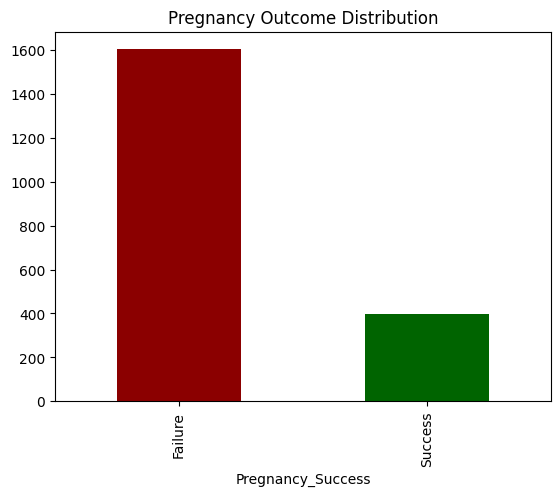

In [237]:
# check the distribution of the target variable
import matplotlib.pyplot as plt

df['Pregnancy_Success'].value_counts().plot(kind='bar',color=['darkred','darkgreen'])
plt.title('Pregnancy Outcome Distribution')
plt.show()

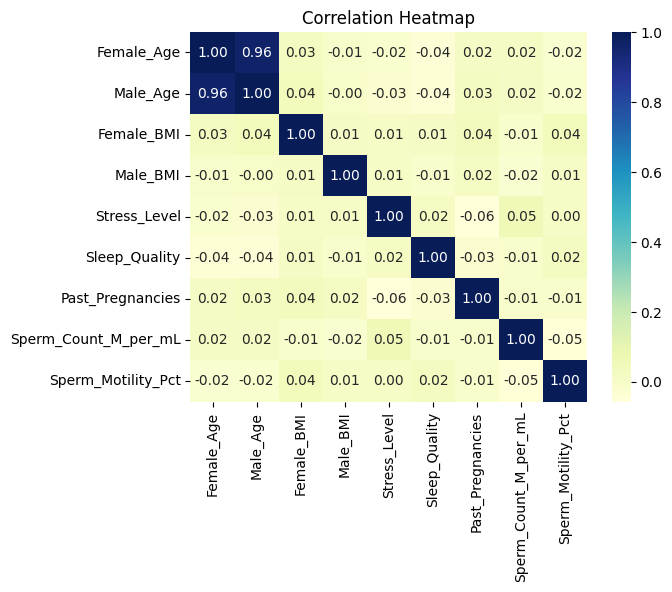

In [238]:
import seaborn as sns
sns.heatmap(df.select_dtypes('number').corr(), annot=True, fmt='.2f', cmap='YlGnBu')
plt.title('Correlation Heatmap')
plt.show()

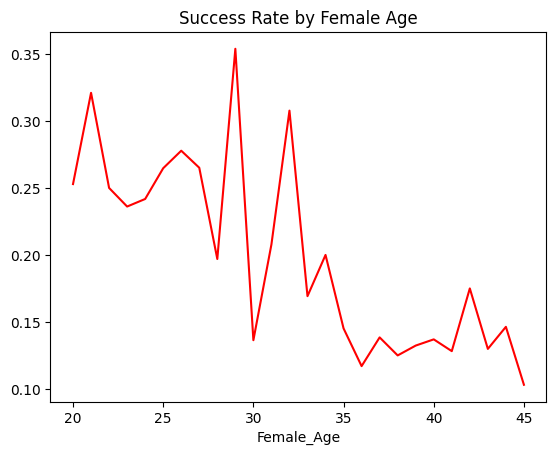

In [239]:
df.groupby('Female_Age')['Pregnancy_Success'].apply(lambda x: (x=='Success').mean()).plot(color='red')
plt.title('Success Rate by Female Age')
plt.show()

In [240]:
df

,Couple_ID,Female_Age,Male_Age,Female_BMI,Male_BMI,PCOS,Period_Regularity,Stress_Level,Sleep_Quality,Past_Pregnancies,Sperm_Count_M_per_mL,Sperm_Motility_Pct,Female_Smokes,Male_Smokes,Female_Alcohol,Male_Alcohol,Female_Exercise,Male_Exercise,Pregnancy_Success
0,CPL0001,26,28,21.1,30.1,No,Regular,5.4,6.1,1,21.6,81.0,No,Yes,Moderate,No_Alcohol,Light,No_Exercise,Failure
1,CPL0002,39,43,24.1,24.6,No,Regular,2.1,5.6,0,41.5,56.8,No,No,Low,High,Light,Active,Failure
2,CPL0003,34,41,25.4,25.9,Yes,Irregular,5.8,5.1,3,64.5,50.8,No,No,No_Alcohol,No_Alcohol,Light,No_Exercise,Success
3,CPL0004,30,33,28.7,30.1,No,Regular,7.2,4.9,2,80.2,46.6,No,No,Moderate,No_Alcohol,No_Exercise,Active,Success
4,CPL0005,27,31,25.1,22.7,Yes,Irregular,6.3,5.3,3,97.2,53.1,No,Yes,Low,Low,Active,Moderate,Failure
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,CPL1996,34,36,20.8,25.9,Yes,Irregular,5.0,6.6,0,61.2,67.1,No,No,Low,No_Alcohol,Moderate,Moderate,Failure
1996,CPL1997,33,40,24.9,17.0,Yes,Irregular,1.8,5.4,0,52.9,39.8,No,No,Low,No_Alcohol,Moderate,Moderate,Failure
1997,CPL1998,37,42,18.7,25.1,Yes,Irregular,6.3,6.7,2,17.6,65.2,No,No,Low,No_Alcohol,Light,Moderate,Failure
1998,CPL1999,39,40,21.4,21.9,No,Regular,8.3,5.7,1,38.3,55.4,No,No,No_Alcohol,Low,Active,Light,Success


In [241]:
# use one-hot encoding to convert categorical variables into numerical format

df_encoded = pd.get_dummies(df, columns=['PCOS','Period_Regularity', 'Female_Smokes', 'Male_Smokes', "Pregnancy_Success"], drop_first=True)
df_encoded

,Couple_ID,Female_Age,Male_Age,Female_BMI,Male_BMI,Stress_Level,Sleep_Quality,Past_Pregnancies,Sperm_Count_M_per_mL,Sperm_Motility_Pct,Female_Alcohol,Male_Alcohol,Female_Exercise,Male_Exercise,PCOS_Yes,Period_Regularity_Regular,Female_Smokes_Yes,Male_Smokes_Yes,Pregnancy_Success_Success
0,CPL0001,26,28,21.1,30.1,5.4,6.1,1,21.6,81.0,Moderate,No_Alcohol,Light,No_Exercise,False,True,False,True,False
1,CPL0002,39,43,24.1,24.6,2.1,5.6,0,41.5,56.8,Low,High,Light,Active,False,True,False,False,False
2,CPL0003,34,41,25.4,25.9,5.8,5.1,3,64.5,50.8,No_Alcohol,No_Alcohol,Light,No_Exercise,True,False,False,False,True
3,CPL0004,30,33,28.7,30.1,7.2,4.9,2,80.2,46.6,Moderate,No_Alcohol,No_Exercise,Active,False,True,False,False,True
4,CPL0005,27,31,25.1,22.7,6.3,5.3,3,97.2,53.1,Low,Low,Active,Moderate,True,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,CPL1996,34,36,20.8,25.9,5.0,6.6,0,61.2,67.1,Low,No_Alcohol,Moderate,Moderate,True,False,False,False,False
1996,CPL1997,33,40,24.9,17.0,1.8,5.4,0,52.9,39.8,Low,No_Alcohol,Moderate,Moderate,True,False,False,False,False
1997,CPL1998,37,42,18.7,25.1,6.3,6.7,2,17.6,65.2,Low,No_Alcohol,Light,Moderate,True,False,False,False,False
1998,CPL1999,39,40,21.4,21.9,8.3,5.7,1,38.3,55.4,No_Alcohol,Low,Active,Light,False,True,False,False,True


In [260]:
# encode the ordinal variables using LabelEncoder

from sklearn.preprocessing import LabelEncoder

order = ["No_Exercise", "Light", "Moderate", "Active"]
mapping = {k: v for v, k in enumerate(order)}
df_encoded['Female_Exercise'] = df_encoded['Female_Exercise'].map(mapping)

order2 = ["No_Exercise", "Light", "Moderate", "Active"]
mapping2 = {k: v for v, k in enumerate(order2)}
df_encoded['Male_Exercise'] = df_encoded['Male_Exercise'].map(mapping2)

order3 = ["No_Alcohol", "Low", "Moderate", "Active","High"]
mapping3 = {k: v for v, k in enumerate(order3)}
df_encoded['Female_Alcohol'] = df_encoded['Female_Alcohol'].map(mapping3)

order4 = ["No_Alcohol", "Low", "Moderate", "Active","High"]
mapping4 = {k: v for v, k in enumerate(order4)}
df_encoded['Male_Alcohol'] = df_encoded['Male_Alcohol'].map(mapping4)

df_encoded = df_encoded.drop('Couple_ID', axis=1)

df_encoded.head()

KeyError: 'Female_Alcohol'

In [ ]:
# Figure out the most important features using a Random Forest Classifier

from sklearn.ensemble import RandomForestClassifier

X = df_encoded.drop('Pregnancy_Success_Success', axis=1)
y = df_encoded['Pregnancy_Success_Success']

model = RandomForestClassifier()
model.fit(X, y)

importances = model.feature_importances_
feature_importance = pd.Series(importances, index=X.columns).sort_values(ascending=False)

print(feature_importance)

Sperm_Motility_Pct           0.122899
Sperm_Count_M_per_mL         0.115039
Female_BMI                   0.100082
Stress_Level                 0.097486
Male_BMI                     0.094281
Sleep_Quality                0.092658
Male_Age                     0.083139
Female_Age                   0.076803
Male_Exercise                0.038545
Male_Alcohol                 0.036441
Female_Exercise              0.033291
Past_Pregnancies             0.031918
Female_Alcohol               0.029299
Period_Regularity_Regular    0.015262
Male_Smokes_Yes              0.012579
PCOS_Yes                     0.011801
Female_Smokes_Yes            0.008476
dtype: float64


In [ ]:
top_features = feature_importance.head(12).index.tolist()
df_encoded = df[list(top_features) + ['Pregnancy_Success']]
df_encoded.head()

,Sperm_Motility_Pct,Sperm_Count_M_per_mL,Female_BMI,Stress_Level,Male_BMI,Sleep_Quality,Male_Age,Female_Age,Male_Exercise,Male_Alcohol,Female_Exercise,Past_Pregnancies,Pregnancy_Success
0,81.0,21.6,21.1,5.4,30.1,6.1,28,26,No_Exercise,No_Alcohol,Light,1,Failure
1,56.8,41.5,24.1,2.1,24.6,5.6,43,39,Active,High,Light,0,Failure
2,50.8,64.5,25.4,5.8,25.9,5.1,41,34,No_Exercise,No_Alcohol,Light,3,Success
3,46.6,80.2,28.7,7.2,30.1,4.9,33,30,Active,No_Alcohol,No_Exercise,2,Success
4,53.1,97.2,25.1,6.3,22.7,5.3,31,27,Moderate,Low,Active,3,Failure


In [ ]:
# check the unique values of the encoded

df_encoded['Male_Age'].unique()

array([28, 43, 41, 33, 31, 47, 29, 46, 40, 45, 35, 36, 27, 44, 24, 32, 21,
       26, 50, 37, 38, 49, 25, 39, 52, 42, 30, 34, 23, 51, 22, 48, 20],
      dtype=int64)

In [ ]:
# convert all columns to numeric, coercing errors to NaN, then fill NaN with 0 and convert to int

df_encoded = df_encoded.apply(pd.to_numeric, errors='coerce').astype(int)
df_encoded

,Sperm_Motility_Pct,Sperm_Count_M_per_mL,Female_BMI,Stress_Level,Male_BMI,Sleep_Quality,Male_Age,Female_Age,Male_Exercise,Male_Alcohol,Female_Exercise,Past_Pregnancies,Pregnancy_Success
0,81,21,21,5,30,6,28,26,0,0,0,1,0
1,56,41,24,2,24,5,43,39,0,0,0,0,0
2,50,64,25,5,25,5,41,34,0,0,0,3,0
3,46,80,28,7,30,4,33,30,0,0,0,2,0
4,53,97,25,6,22,5,31,27,0,0,0,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,67,61,20,5,25,6,36,34,0,0,0,0,0
1996,39,52,24,1,17,5,40,33,0,0,0,0,0
1997,65,17,18,6,25,6,42,37,0,0,0,2,0
1998,55,38,21,8,21,5,40,39,0,0,0,1,0


In [ ]:
# prepare the features and target variable for modeling

feature_names = df_encoded.columns.tolist()
#feature_names.remove('Pregnancy_Success_Success')

all_features = df_encoded[feature_names].values
all_classes = df_encoded['Pregnancy_Success'].values

print(all_features)
print(all_classes[0:10])

[[81 21 21 ...  0  1  0]
 [56 41 24 ...  0  0  0]
 [50 64 25 ...  0  3  0]
 ...
 [65 17 18 ...  0  2  0]
 [55 38 21 ...  0  1  0]
 [66 33 17 ...  0  1  0]]
[0 0 0 0 0 0 0 0 0 0]


In [ ]:
# standardize the features using StandardScaler

from sklearn.preprocessing import StandardScaler
all_features = StandardScaler().fit_transform(all_features)
all_features

array([[ 1.7637513 , -1.49252934, -0.65142457, ...,  0.        ,
         0.24658186,  0.        ],
       [ 0.08193795, -0.48153609,  0.11767173, ...,  0.        ,
        -0.85669268,  0.        ],
       [-0.32169726,  0.68110615,  0.37403717, ...,  0.        ,
         2.45313093,  0.        ],
       ...,
       [ 0.68739075, -1.69472799, -1.42052087, ...,  0.        ,
         1.3498564 ,  0.        ],
       [ 0.01466541, -0.63318507, -0.65142457, ...,  0.        ,
         0.24658186,  0.        ],
       [ 0.75466329, -0.88593339, -1.67688631, ...,  0.        ,
         0.24658186,  0.        ]])

In [ ]:
# split the data into training and testing sets

from sklearn.model_selection import train_test_split
y = df_encoded["Pregnancy_Success"]
X = df_encoded[feature_names]
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.75, test_size=0.25)

In [ ]:
# evaluate select_a_df_row using the different classifiers and print the predicted probabilities for each class

random_record = 16

select_a_x_row = X_test.iloc[[random_record]]
select_a_y_row = y_test.iloc[random_record]
print(select_a_x_row)
print(select_a_y_row)

      Sperm_Motility_Pct  Sperm_Count_M_per_mL  Female_BMI  Stress_Level  \
1598                  95                    40          16             3   

      Male_BMI  Sleep_Quality  Male_Age  Female_Age  Male_Exercise  \
1598        22              7        32          31              0   

      Male_Alcohol  Female_Exercise  Past_Pregnancies  Pregnancy_Success  
1598             0                0                 0                  0  
0


In [ ]:
# define a dictionary of classifiers to evaluate using cross-validation

from sklearn.model_selection import cross_val_score
from sklearn import svm
from sklearn import tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

classifiers = {}
classifiers["DecisionTreeClassifier"] = tree.DecisionTreeClassifier()

for c in [0.1, 1, 3, 10]:
    for kernel in ['linear','poly','rbf','sigmoid']:
        classifiers[f"svm_{c}_{kernel}"] = svm.SVC(kernel=kernel, C=c)

for k in range(2,30):
  for neighbors in range(2,10):
    classifiers[f"KNeighborsClassifier{k}_{neighbors}"] = KNeighborsClassifier(n_neighbors=neighbors, algorithm='kd_tree')

# classifiers["MultinomialNB"] = MultinomialNB()

for max_iter in [100, 500, 1000, 2000, 5000, 10000]:
  classifiers[f"LogisticRegression_{max_iter}"] = LogisticRegression(max_iter=max_iter)


In [ ]:
# evaluate each classifier using cross-validation and print the mean and standard deviation of the scores

max_score = 0
max_kernel = None

for name, clf in classifiers.items():
    clf_fit = clf.fit(X_train, y_train)
    cv_scores_temp = cross_val_score(clf_fit, all_features, all_classes, cv=2)
    print(f"{name}: {cv_scores_temp.mean():.3f} (+/- {cv_scores_temp.std() * 2:.3f})")
    if cv_scores_temp.mean() > max_score:
        max_score = cv_scores_temp.mean()
        max_kernel = name

print(f"Best classifier: {max_kernel} with score {max_score:.3f}")

DecisionTreeClassifier: 1.000 (+/- 0.000)


ValueError: The number of classes has to be greater than one; got 1 class

In [ ]:
# evaluate select_a_df_row using the different classifiers and print the predicted probabilities for each class
print("Real value:", select_a_y_row)

for name, clf in classifiers.items():
    clf_fit = clf.fit(X_train, y_train)
    prediction = clf_fit.predict(select_a_x_row)
    print(f"{name}: {prediction}")

Real value: 0
DecisionTreeClassifier: [0]
svm_0.1_linear: [0]
svm_0.1_poly: [0]
svm_0.1_rbf: [0]
svm_0.1_sigmoid: [0]
svm_1_linear: [0]
svm_1_poly: [0]
svm_1_rbf: [0]
svm_1_sigmoid: [0]
svm_3_linear: [0]
svm_3_poly: [0]
svm_3_rbf: [0]
svm_3_sigmoid: [0]
svm_10_linear: [0]
svm_10_poly: [0]
svm_10_rbf: [0]
svm_10_sigmoid: [0]
KNeighborsClassifier2_2: [0]
KNeighborsClassifier2_3: [0]
KNeighborsClassifier2_4: [0]
KNeighborsClassifier2_5: [0]
KNeighborsClassifier2_6: [0]
KNeighborsClassifier2_7: [0]
KNeighborsClassifier2_8: [0]
KNeighborsClassifier2_9: [0]
KNeighborsClassifier3_2: [0]
KNeighborsClassifier3_3: [0]
KNeighborsClassifier3_4: [0]
KNeighborsClassifier3_5: [0]
KNeighborsClassifier3_6: [0]
KNeighborsClassifier3_7: [0]
KNeighborsClassifier3_8: [0]
KNeighborsClassifier3_9: [0]
KNeighborsClassifier4_2: [0]
KNeighborsClassifier4_3: [0]
KNeighborsClassifier4_4: [0]
KNeighborsClassifier4_5: [0]
KNeighborsClassifier4_6: [0]
KNeighborsClassifier4_7: [0]
KNeighborsClassifier4_8: [0]
KNeighb

C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression_100: [0]


C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression_500: [0]
LogisticRegression_1000: [0]
LogisticRegression_2000: [0]
LogisticRegression_5000: [0]
LogisticRegression_10000: [0]
